In [ ]:
from langchain.agents import create_agent
from langchain.tools import tool, ToolRuntime
from dataclasses import dataclass
from langchain.chat_models import init_chat_model
from langgraph.checkpoint.memory import InMemorySaver

# 1. 详细的系统提示以获得更好的代理行为
SYSTEM_PROMPT = """
你是一个专家级天气预报员，能够提供准确的天气信息和预测。

你可以使用以下工具来获取天气数据：
1. get_weather(location: str) -> str: 获取指定位置的当前天气情况。
请根据用户的请求使用这些工具来提供详细的天气信息，并确保你的回答清晰、准确且易于理解。
2. get_user_location() -> str: 获取用户当前的位置

如果用户没有提供位置，请使用get_user_location工具来获取用户的位置，以便提供相关的天气信息。

"""

# 2. 创建与外部数据集成的工具
@tool #装饰器将函数注册为工具，使其可以被智能体调用
def get_weather(location):
    """根据location位置获取天气信息"""
    return f"{location}的天气是晴朗，温度25度。"

@dataclass
class MyContext:
    """定义一个上下文类来存储用户信息"""
    user_id: str

# agent在调用该工具时需要获取上下文信息，在上下文中区分不同用户
@tool
def get_user_location(runtime: ToolRuntime[MyContext]):
    """获取用户当前的位置"""
    user_id = runtime.context.user_id #从上下文中获取用户ID
    # 在实际的业务场景中肯定需要通过user_id去查询业务系统获取具体用户身份
    if user_id == "user_123":
        return "上海"
    else:
        return "北京"

# 3. 模型配置以获得一致的响应:创建模型的方式不依赖具体模型供应商
model = init_chat_model(
    model="deepseek-chat",
    temperature=0.7,
    max_tokens=1000,
    api_key="sk-f61f7b6587da47bfbeb2f8f7232a37d3"
)

# 4. 结构化输出以获得可预测的结果
@dataclass
class ResponseFormat:
    """定义一个结构化的响应格式"""
    location: str #用户请求的地点
    weather: str #天气信息
    response: str #智能体的回复内容


# 5. 对话记忆以进行类似聊天的交互
memory_saver = InMemorySaver() #使用内存保存对话历史记录

In [3]:
# 6. 创建并运行代理以创建功能齐全的代理
agent = create_agent(
    model=model,                            # 使用的语言模型
    tools=[get_weather, get_user_location], # 工具列表，可以添加多个工具，也可以是空
    system_prompt=SYSTEM_PROMPT,            #定义系统提示词
    response_format=ResponseFormat,         # 定义响应格式
    checkpointer=memory_saver,              # 使用内存保存对话历史记录
)

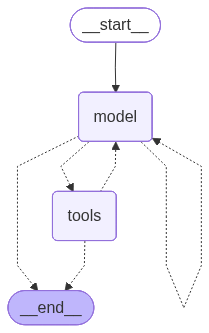

In [4]:
agent

In [5]:
message = {
    "messages":[
        {"role":"user", "content":"今天天气怎么样？"}
    ]
}

#标记当次聊天
config = {
    "configurable":{"thread_id":"1"}
}
response = agent.invoke(
    message,
    config=config, 
    context=MyContext(user_id="user_123")
    )

In [6]:
response

{'messages': [HumanMessage(content='今天天气怎么样？', additional_kwargs={}, response_metadata={}, id='806fc269-26d3-470a-9ed1-5d6f7e837219'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 513, 'total_tokens': 534, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 513}, 'model_provider': 'deepseek', 'model_name': 'deepseek-chat', 'system_fingerprint': 'fp_eaab8d114b_prod0820_fp8_kvcache_new_kvcache_20260410', 'id': '17ba4ded-a3ca-4ea6-8492-a7c49748a5a7', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d857f-ca20-7ff0-9ac6-d741979752d8-0', tool_calls=[{'name': 'get_user_location', 'args': {}, 'id': 'call_00_eUAfQraRwOGsi896bRgEVxlI', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 513, 'output_tokens': 21, 'total_tokens': 534, 'input_token_details'

In [7]:
print(response["structured_response"])

ResponseFormat(location='上海', weather='晴朗，温度25度', response='根据您的位置信息，今天上海的天气非常不错！天气晴朗，温度适宜，为25度。这是一个非常适合户外活动的好天气，建议您可以安排一些户外活动，享受这美好的天气。记得适当防晒，保持水分补充。')


In [8]:
message = {
    "messages":[
        {"role":"user", "content":"刚才问的是什么地方的天气？"}
    ]
}

#标记当次聊天
config = {
    "configurable":{"thread_id":"1"}
}
response = agent.invoke(
    message,
    config=config
    )

Deserializing unregistered type __main__.ResponseFormat from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'ResponseFormat')]


In [9]:
response

{'messages': [HumanMessage(content='今天天气怎么样？', additional_kwargs={}, response_metadata={}, id='806fc269-26d3-470a-9ed1-5d6f7e837219'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 513, 'total_tokens': 534, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 513}, 'model_provider': 'deepseek', 'model_name': 'deepseek-chat', 'system_fingerprint': 'fp_eaab8d114b_prod0820_fp8_kvcache_new_kvcache_20260410', 'id': '17ba4ded-a3ca-4ea6-8492-a7c49748a5a7', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d857f-ca20-7ff0-9ac6-d741979752d8-0', tool_calls=[{'name': 'get_user_location', 'args': {}, 'id': 'call_00_eUAfQraRwOGsi896bRgEVxlI', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 513, 'output_tokens': 21, 'total_tokens': 534, 'input_token_details'